SETUP

In [1]:
import random
import numpy as np
import keras
from keras import ops
import matplotlib.pyplot as plt

HYPERPARAMETERS

In [2]:
epochs = 10
batch_size = 16
margin = 1 

LOAD THE "MNIST" DATASET

In [3]:
(x_train_val, y_train_val), (x_test, y_test) = keras.datasets.mnist.load_data()

# Change the data type to a floating point format
x_train_val = x_train_val.astype("float32")
x_test = x_test.astype("float32")

DEFINE TRAINING AND VALIDATION SETS

In [4]:
x_train, x_val = x_train_val[:30000], x_train_val[30000:]
y_train, y_val = y_train_val[:30000], y_train_val[30000:]
del x_train_val, y_train_val

CREATE PAIRS OF IMAGES

In [5]:
def make_pairs(x, y):

    num_classes = max(y) + 1
    digit_indices = [np.where(y == i)[0] for i in range(num_classes)]

    pairs = []
    labels = []

    for idx1 in range(len(x)):
        # add a matching example
        x1 = x[idx1]
        label1 = y[idx1]
        idx2 = random.choice(digit_indices[label1])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [0]

        # add a non-matching example
        label2 = random.randint(0, num_classes - 1)
        while label2 == label1:
            label2 = random.randint(0, num_classes - 1)

        idx2 = random.choice(digit_indices[label2])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [1]

    return np.array(pairs), np.array(labels).astype("float32")


# make train pairs
pairs_train, labels_train = make_pairs(x_train, y_train)

# make validation pairs
pairs_val, labels_val = make_pairs(x_val, y_val)

# make test pairs
pairs_test, labels_test = make_pairs(x_test, y_test)

In [6]:
x_train_1 = pairs_train[:, 0]  
x_train_2 = pairs_train[:, 1]

In [7]:
x_val_1 = pairs_val[:, 0]  
x_val_2 = pairs_val[:, 1]


In [8]:
x_test_1 = pairs_test[:, 0]  
x_test_2 = pairs_test[:, 1]

VISUALIZE PAIRS AND THEIR LABELS

In [9]:
def visualize(pairs, labels, to_show=6, num_col=3, predictions=None, test=False):
    
    num_row = to_show // num_col if to_show // num_col != 0 else 1

    to_show = num_row * num_col

    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))
    for i in range(to_show):
        if num_row == 1:
            ax = axes[i % num_col]
        else:
            ax = axes[i // num_col, i % num_col]

        ax.imshow(ops.concatenate([pairs[i][0], pairs[i][1]], axis=1), cmap="gray")
        ax.set_axis_off()
        if test:
            ax.set_title("True: {} | Pred: {:.5f}".format(labels[i], predictions[i][0]))
        else:
            ax.set_title("Label: {}".format(labels[i]))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    plt.show()

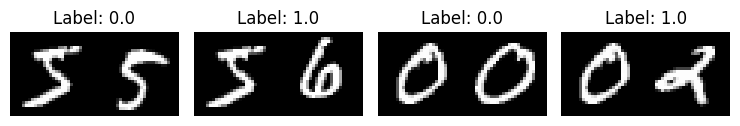

In [15]:
visualize(pairs_train[:-1], labels_train[:-1], to_show=4, num_col=4)

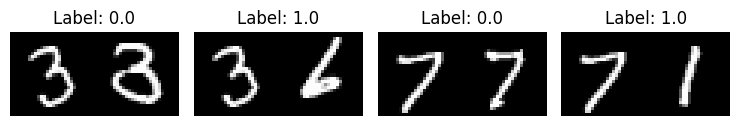

In [11]:
visualize(pairs_val[:-1], labels_val[:-1], to_show=4, num_col=4)

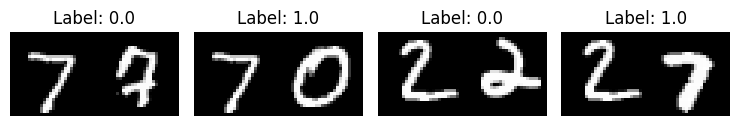

In [12]:
visualize(pairs_test[:-1], labels_test[:-1], to_show=4, num_col=4)

DEFINE THE MODEL

In [10]:
def euclidean_distance(vects):
    x, y = vects
    sum_square = ops.sum(ops.square(x - y), axis=1, keepdims=True)
    return ops.sqrt(ops.maximum(sum_square, keras.backend.epsilon()))


input = keras.layers.Input((28, 28, 1))
x = keras.layers.BatchNormalization()(input)
x = keras.layers.Conv2D(4, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(16, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Flatten()(x)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(10, activation="tanh")(x)
embedding_network = keras.Model(input, x)


input_1 = keras.layers.Input((28, 28, 1))
input_2 = keras.layers.Input((28, 28, 1))

tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))(
    [tower_1, tower_2]
)
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

DEFINE THE CONTRASTIVE LOSS

In [11]:
def loss(margin=1):
    def contrastive_loss(y_true, y_pred):
      
        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

COMPILE THE MODEL WITH THE CONTRASTIVE LOSS

In [12]:
siamese.compile(loss=loss(margin=margin), optimizer="RMSprop", metrics=["accuracy"])
siamese.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ functional (Functional)       │ (None, 10)                │           5,318 │ input_layer_1[0][0],       │
│                               │                           │                 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda (Lambda)               │ (None, 1)                 │               0 │ functional[0][0],          │
│                               │                           │                 │ functional[1][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 1)                 │               4 │ lambda[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │               2 │ batch_normalization_2[0][… │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 5,324 (20.80 KB)

 Trainable params: 4,808 (18.78 KB)

 Non-trainable params: 516 (2.02 KB)

TRAIN THE MODEL

In [13]:
history = siamese.fit(
    [x_train_1, x_train_2],
    labels_train,
    validation_data=([x_val_1, x_val_2], labels_val),
    batch_size=batch_size,
    epochs=epochs,
)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 106s 27ms/step - accuracy: 0.5927 - loss: 0.2205 - val_accuracy: 0.9471 - val_loss: 0.0407
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 98s 26ms/step - accuracy: 0.9225 - loss: 0.0586 - val_accuracy: 0.9609 - val_loss: 0.0300
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 111s 30ms/step - accuracy: 0.9378 - loss: 0.0471 - val_accuracy: 0.9695 - val_loss: 0.0239
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 105s 28ms/step - accuracy: 0.9474 - loss: 0.0403 - val_accuracy: 0.9760 - val_loss: 0.0187
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 147s 29ms/step - accuracy: 0.9540 - loss: 0.0355 - val_accuracy: 0.9753 - val_loss: 0.0189
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 114s 30ms/step - accuracy: 0.9563 - loss: 0.0334 - val_accuracy: 0.9756 - val_loss: 0.0192
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 139s 30ms/step - accuracy: 0.9618 - loss: 0.0296 - val_accuracy: 0.9807 - val_loss: 0.0150
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 141s 29ms/step - accuracy: 0

VISUALIZE RESULTS

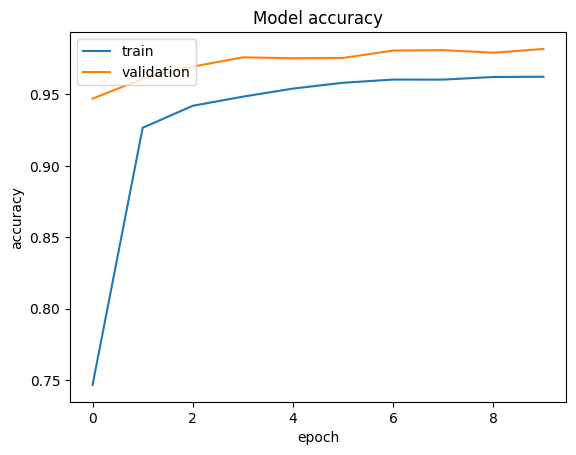

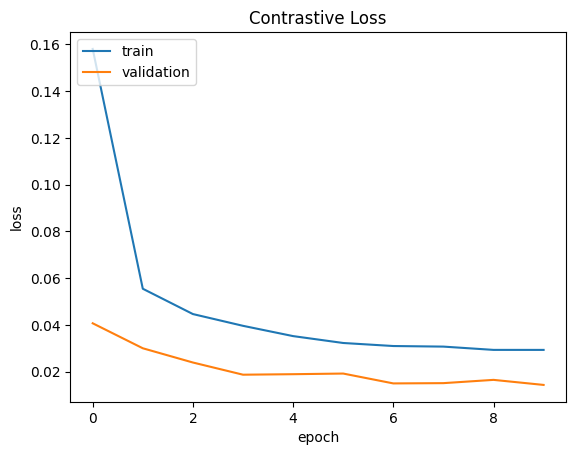

In [14]:
def plt_metric(history, metric, title, has_valid=True):
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()

plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

plt_metric(history=history.history, metric="loss", title="Contrastive Loss")

EVALUATE THE MODEL

In [15]:
results = siamese.evaluate([x_test_1, x_test_2], labels_test)
print("test loss, test acc:", results)

625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9829 - loss: 0.0138
test loss, test acc: [0.013132264837622643, 0.9833499789237976]


VISUALIZE THE PREDICTIONS

625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


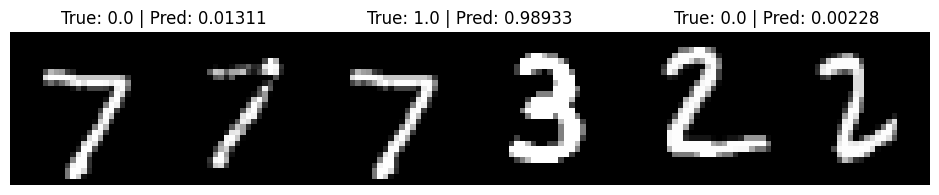

In [16]:
predictions = siamese.predict([x_test_1, x_test_2])
visualize(pairs_test, labels_test, to_show=3, predictions=predictions, test=True)